<a href="https://colab.research.google.com/github/Chirag240105/Machine_Learning/blob/main/Student_Performance_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import os
from google.colab import files

# Upload your kaggle.json token
uploaded = files.upload()

# Secure and move the token to the correct directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [12]:
# STEP 4: Download dataset
!kaggle datasets download -d nikhil7280/student-performance-multiple-linear-regression


Dataset URL: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
License(s): other
student-performance-multiple-linear-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
# STEP 5: Unzip dataset
!unzip student-performance-multiple-linear-regression.zip

Archive:  student-performance-multiple-linear-regression.zip
replace Student_Performance.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
data = pd.read_csv("Student_Performance.csv")

In [16]:
df = pd.DataFrame(data)
df.head(15)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [17]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [29]:
df.drop_duplicates()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [30]:
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities']) #Yes -> 1 || No -> 0

In [31]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


+1 → strong positive relation
-1 → strong negative relation
0 → weak/no relation

Example: if Hours Studied has high correlation with Performance Index, then study hours strongly affect score.

In [32]:
X = df.drop(['Performance Index'], axis=1)
y = df['Performance Index']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean abosolute error: ", mae)
print("Mean squared error: ", mse)
print("Root mean square: ", rmse)
print("R2 score: ", r2)


Mean abosolute error:  1.6111213463123044
Mean squared error:  4.082628398521853
Root mean square:  2.0205515085050054
R2 score:  0.9889832909573145


*MAE → average prediction error. Lower is better.
MSE → squared error. Penalizes big mistakes.
RMSE → error in same unit as target.
R2 Score → model accuracy-like score*

# Feature Importance

model.coef_ gives weight of each feature.

Higher positive coefficient means that feature increases performance more.

Example:

If Previous Scores coefficient is high, previous marks strongly affect final performance.

In [38]:
importance  = pd.DataFrame({
    "Features" : X.columns,
    "Coefficient" : model.coef_
})

importance.sort_values(by="Coefficient", ascending=False)

,Features,Coefficient
0,Hours Studied,2.852484
1,Previous Scores,1.016988
2,Extracurricular Activities,0.608617
3,Sleep Hours,0.476941
4,Sample Question Papers Practiced,0.191831


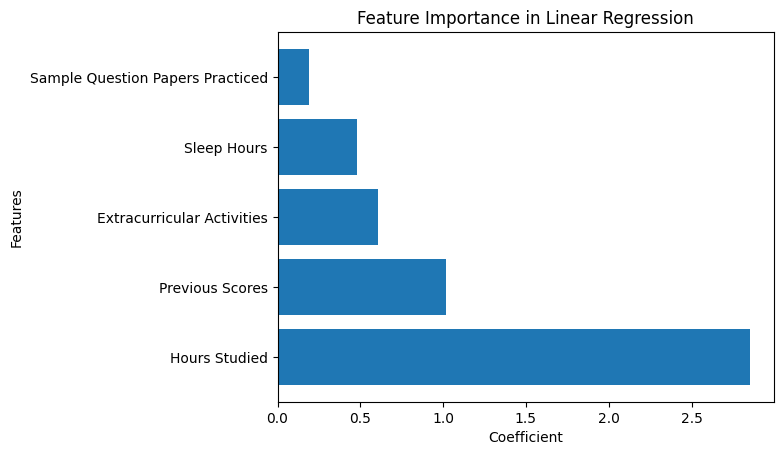

In [39]:
plt.barh(importance["Features"], importance["Coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Importance in Linear Regression")
plt.show()

Prediction in new Student

In [69]:
new_student = pd.DataFrame([
    {
        "Hours Studied": 7,
        "Previous Scores": 85,
        "Extracurricular Activities": 1,
        "Sleep Hours": 8,
        "Sample Question Papers Practiced": 5
    },
    {
        "Hours Studied": 4,
        "Previous Scores": 62,
        "Extracurricular Activities": 0,
        "Sleep Hours": 5,
        "Sample Question Papers Practiced": 2
    },
    {
        "Hours Studied": 8,
        "Previous Scores": 92,
        "Extracurricular Activities": 1,
        "Sleep Hours": 8,
        "Sample Question Papers Practiced": 12
    },
    {
        "Hours Studied": 9,
        "Previous Scores": 92,
        "Extracurricular Activities": 1,
        "Sleep Hours": 8,
        "Sample Question Papers Practiced": 4
    }
])

In [70]:
prediction = model.predict(new_student)

print("Predicted Performance Index:", prediction)

Predicted Performance Index: [77.87274396 43.30962814 89.18696538 90.50479778]


***$$\text{Predicted Performance} = (w_1 \times \text{Hours}) + (w_2 \times \text{Prev Score}) + \dots + \text{Intercept}$$***